In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

import sys
sys.path.append("../")

def retime(df):
    """
    Recalculate segment time, treating the entire dataframe as one segment.

    Args:
        df (pd.DataFrame): Measurement data. Includes a column
                           'Segment Time, S'

    Returns:
        pd.DataFrame: Dataframe where 'Segment Time, S' is reindexed
                      to start from 0.
    """
    df_ = df.copy().reset_index(drop=True)
    df_["Segment Time, S"] = df_["Total Time, S"] - df_.loc[0, "Total Time, S"]
    return df_

hdf = pd.HDFStore('../data/data_raw.h5', mode='r')
keys = hdf.keys()

In [2]:
idx_A = np.nonzero(["_A_" in key for key in keys])
df = hdf.get(keys[idx_A[0][0]])

In [3]:
segments_of_interest = [
    "Charge depleting cycle",
    "Charge sustaining cycle",
    'Rate test C/2 cycle charge CC',
    'PsRP 1 C/2 diagnostic cycle charge',
    'PsRP 2 C/2 diagnostic cycle charge',
    'Rate test 1C cycle charge CC',
    'PsRP 1 1C diagnostic cycle charge',
    'PsRP 2 1C diagnostic cycle charge',
]

Feature processing plan:
- "Charge depleting cycle",
    - has 10 minute repeats of power control
    - split into 10 minute windows (every 600 rows exactly)
    - for each window, extract final 2 minutes [:-120] for held out test set input
    - extract 5 random 120s windows from the first 8 minutes for training set input
    - target is C/3 discharge capacity
- "Charge sustaining cycle",
    - last 30 minutes pull out for held out test set input
    - first 1.5 hours, pull out 5 random 30 minute segments
- 'Rate test C/2 cycle charge CC',
    - grab 10x random 15 minute windows
- 'PsRP 1 C/2 diagnostic cycle charge',
    - grab 10x random 15 minute windows
- 'PsRP 2 C/2 diagnostic cycle charge',
    - grab 10x random 15 minute windows
- 'Rate test 1C cycle charge CC',
    - grab 10x random 8 minute windows
- 'PsRP 1 1C diagnostic cycle charge',
    - grab 10x random 8 minute windows
- 'PsRP 2 1C diagnostic cycle charge',
    - grab 10x random 8 minute windows

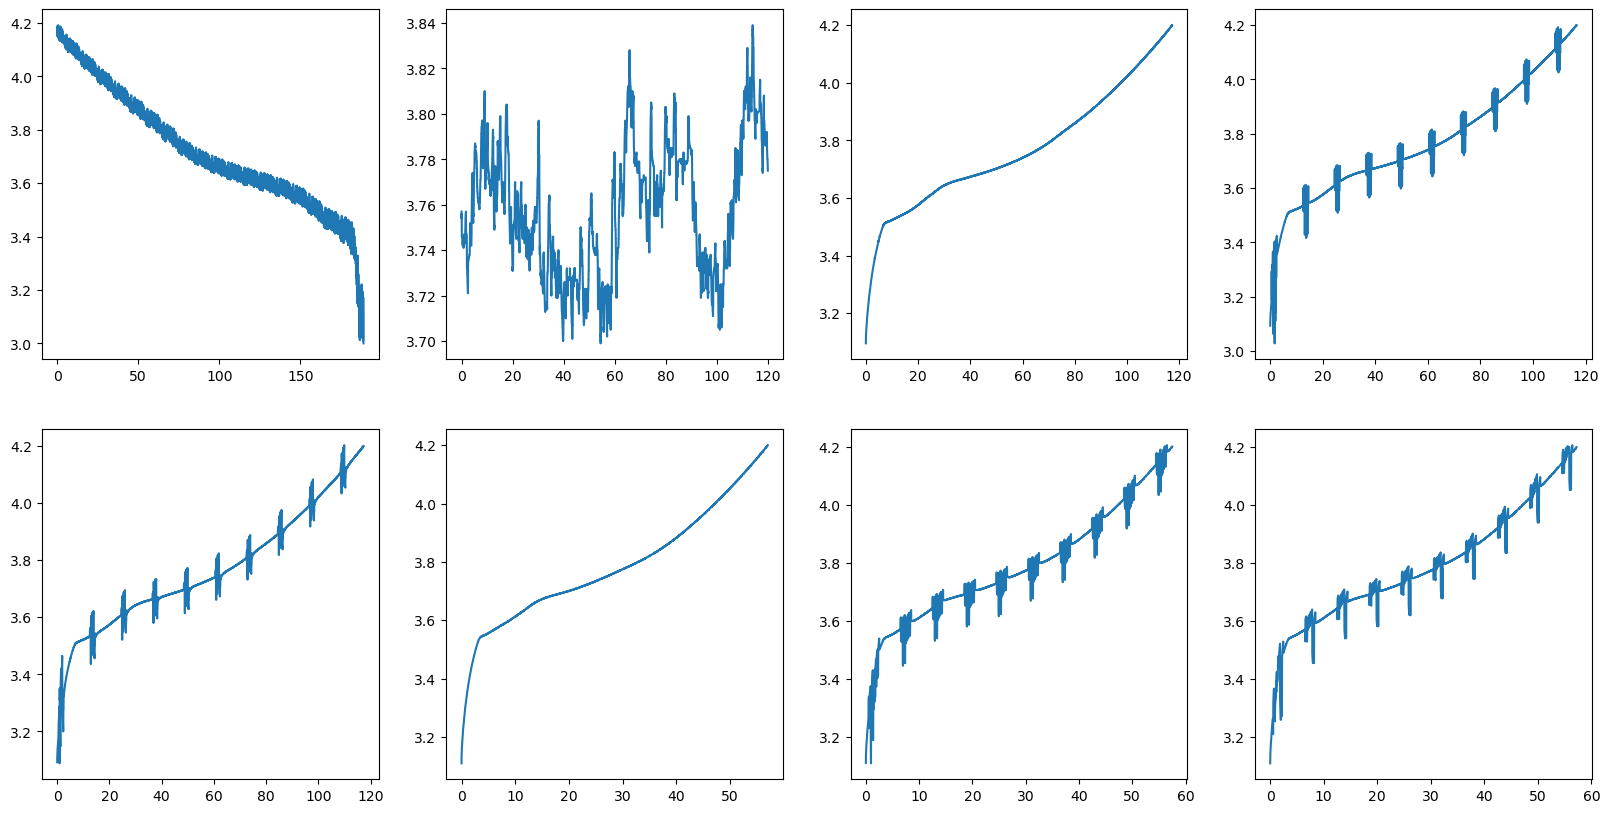

In [4]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))
ax = ax.flatten()
for i, segment in enumerate(segments_of_interest):
    # filter df for any rows where the col 'Segment Description' contains segment
    df_segment = df.loc[[segment in seg_desc and 'rest' not in seg_desc and 'CV' not in seg_desc for seg_desc in df['Segment Description']]]
    df_segment = retime(df_segment)
    ax[i].plot(df_segment['Segment Time, S'] / 60, df_segment['Voltage, V'])